# Entrenamiento de modelo de regresión de puntuación


## Importación de librerias necesarias


In [1]:
%load_ext IPython.extensions.autoreload
%autoreload 2


In [2]:
import os
from pathlib import Path
import sys

def find_src_folder(current_path: Path, folder_name: str = 'src') -> Path:
    search_directories = [current_path] + list(current_path.parents)
    for parent in search_directories:
        if parent.name == folder_name:
            return parent.parent
    return current_path

src_path = find_src_folder(Path.cwd(), 'src')
sys.path.append(str(src_path))

print(f"JAVA_HOME: {os.environ.get('JAVA_HOME')}")
print(f"TFHUB_CACHE_DIR: {os.environ.get('TFHUB_CACHE_DIR')}")


JAVA_HOME: /usr/lib/jvm/java-11-openjdk-amd64
TFHUB_CACHE_DIR: /mnt/d/Maestría/Amazon Reviews Code/tf_cache


In [3]:
import numpy as np
import pandas as pd
import sys
import os
import shutil
import tensorflow as tf
import tensorflow_io as tfio
from pyspark.sql import functions as F, types as T, DataFrame
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from pyspark.ml.functions import array_to_vector, vector_to_array
from pyspark.ml.feature import VectorAssembler


2025-11-05 02:58:10.656519: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-11-05 02:58:10.668722: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-11-05 02:58:10.672096: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-11-05 02:58:10.682115: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-05 02:58:12.357023: W tensorflow/compiler/tf2

In [4]:
print(f"Python executable: {sys.executable}")
print(f"Python version: {sys.version}")
print(f"TensorFlow version: {tf.__version__}")
print(f"CUDA built: {tf.test.is_built_with_cuda()}")

gpus = tf.config.list_physical_devices('GPU')
print(f"GPU devices: {gpus}")

if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("GPU memory growth enabled")
    except RuntimeError as e:
        print(f"GPU memory growth error: {e}")

if gpus:
    with tf.device('/GPU:0'):
        a = tf.constant([[1.0, 2.0], [3.0, 4.0]])
        b = tf.constant([[2.0, 0.0], [0.0, 2.0]])
        c = tf.matmul(a, b)
        print(f"GPU test result: {c.numpy()}")
        print("✓ GPU is working!")
else:
    print("❌ No GPU detected")


Python executable: /mnt/d/Maestría/Amazon Reviews Code/.venv-linux/bin/python
Python version: 3.11.13 (main, Jun  4 2025, 08:57:30) [GCC 13.3.0]
TensorFlow version: 2.17.1
CUDA built: True
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU memory growth enabled
GPU test result: [[2. 4.]
 [6. 8.]]
✓ GPU is working!


I0000 00:00:1762329496.974100 1091943 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1762329497.016277 1091943 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1762329497.016485 1091943 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1762329497.018529 1091943 cuda_executor.cc:1015] successful NUMA node read from SysFS ha

In [5]:
from src.utils.spark import SparkUtils, METASTORE_PATH
spark_utils = SparkUtils('predict_category_model')
spark = spark_utils.spark


:: loading settings :: url = jar:file:/mnt/d/Maestr%c3%ada/Amazon%20Reviews%20Code/.venv-linux/lib/python3.11/site-packages/pyspark/jars/ivy-2.5.1.jar!/org/apache/ivy/core/settings/ivysettings.xml


Ivy Default Cache set to: /home/edgar/.ivy2/cache
The jars for the packages stored in: /home/edgar/.ivy2/jars
io.delta#delta-spark_2.12 added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-322c7d37-9f5e-4276-ac0a-2605a512f91a;1.0
	confs: [default]
	found io.delta#delta-spark_2.12;3.0.0 in central
	found io.delta#delta-storage;3.0.0 in central
	found org.antlr#antlr4-runtime;4.9.3 in central
:: resolution report :: resolve 104ms :: artifacts dl 3ms
	:: modules in use:
	io.delta#delta-spark_2.12;3.0.0 from central in [default]
	io.delta#delta-storage;3.0.0 from central in [default]
	org.antlr#antlr4-runtime;4.9.3 from central in [default]
	---------------------------------------------------------------------
	|                  |            modules            ||   artifacts   |
	|       conf       | number| search|dwnlded|evicted|| number|dwnlded|
	---------------------------------------------------------------------
	|      default     |   3   |   0   

## Cargar datos fuente de entrenamiento


In [6]:
GOLD_ENCODING = 'gold.encoding'
GOLD_PREMODELING = 'gold.premodeling'
GOLD_SCHEMA_CLUSTER = 'gold.cluster'
SCHEMA = 'silver.preprocess'


In [7]:
REGENERATE_MODEL = False


In [8]:
src_dir_regression = f"{METASTORE_PATH}/warehouse/gold.premodeling/final_training_data_rating_array_regression"
dst_dir_regression = f"{METASTORE_PATH}/warehouse/gold.premodeling/dataset_score_model_regression"
dst_path_regression = os.path.join(dst_dir_regression, "dataset_training.parquet")


In [22]:
from src.utils.models import RegressionModel
regression_model = RegressionModel('regression_model', METASTORE_PATH, tracking_uri="file:///mnt/d/Maestría/Amazon Reviews Code/.mlflow")
regression_model.input_shape = 314
regression_model.create_model()

<Sequential name=sequential_7, built=True>

In [25]:
from tensorflow.keras.utils import model_to_dot
import pydot

dot = model_to_dot(
    regression_model.model,
    show_shapes=True,
    show_layer_names=True,
    rankdir="LR",
    expand_nested=True
)

dot.set_graph_defaults(
    rankdir="LR",
    ranksep="1.2",
    nodesep="0.8",
    splines="ortho",
    concentrate="false",
    newrank="true",
    bgcolor="#ffffff"
)

for node in dot.get_node_list():
    node.set_style("filled,rounded")
    node.set_fillcolor("#ffffff")
    node.set_fontcolor="#ffffff"
    node.set_fontname("Arial")
    node.set_fontsize("9")
    node.set_color("#444444")
    node.set_penwidth("1.0")

nodes = [n for n in dot.get_node_list() if n.get_name() not in ('node',)]
print(len(nodes))
for i in range(0, len(nodes), 4):
    subgraph = pydot.Cluster(f"cluster_row_{i}", label="", style="invis", rank="same")
    for n in nodes[i:i+4]:
        subgraph.add_node(n)
    dot.add_subgraph(subgraph)

dot.write_png(f"{METASTORE_PATH}/warehouse/gold.premodeling/binary_model4.png")

15


In [10]:
regression_model = RegressionModel('regression_model', METASTORE_PATH, tracking_uri="file:///mnt/d/Maestría/Amazon Reviews Code/.mlflow")


In [11]:
regression_model.prepare_data(
    spark, src_dir_regression, dst_dir_regression, dst_path_regression, target_column=b"rating_regression", shuffle_buffer_size = -1,
    train_ratio=0.8, val_ratio=0.1
)


2025-10-19 20:55:32.014051: I tensorflow_io/core/kernels/cpu_check.cc:128] Your CPU supports instructions that this TensorFlow IO binary was not compiled to use: SSE3 SSE4.1 SSE4.2 AVX AVX2 FMA


## Crear modelo de predicción


In [12]:
regression_model.create_model()


<Sequential name=sequential, built=True>

In [13]:
if True:
    history_model_regression = regression_model.train(epochs=20)


Epoch 1/20


I0000 00:00:1760925370.527361  405864 service.cc:146] XLA service 0x7db630019030 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1760925370.527380  405864 service.cc:154]   StreamExecutor device (0): NVIDIA GeForce RTX 3050, Compute Capability 8.6
2025-10-19 20:56:10.554718: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-10-19 20:56:10.695860: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 8907


      5/Unknown 13s 46ms/step - loss: 0.2064 - mae: 0.4428

I0000 00:00:1760925372.088913  405864 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


    625/Unknown 53s 66ms/step - loss: 0.1040 - mae: 0.2688

...

2025-10-19 21:11:38.211646: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
	 [[IteratorGetNext/_2]]
2025-10-19 21:11:38.211698: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 12009864852885020793
2025-10-19 21:11:38.211711: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 15738707333368919069


625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - loss: 0.0761 - mae: 0.2283

2025-10-19 21:12:34.685876: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 12009864852885020793
2025-10-19 21:12:34.685916: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 15738707333368919069



Epoch 9: val_loss did not improve from 0.08968
625/625 ━━━━━━━━━━━━━━━━━━━━ 112s 164ms/step - loss: 0.0658 - mae: 0.2070 - val_loss: 0.0911 - val_mae: 0.2219 - learning_rate: 5.0000e-04
Epoch 9: early stopping
Restoring model weights from the end of the best epoch: 6.


2025-10-19 21:13:30.464427: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 12009864852885020793
2025-10-19 21:13:30.464454: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 15738707333368919069


2025/10/19 21:13:33 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/10/19 21:13:33 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.
2025/10/19 21:13:46 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
/mnt/d/Maestría/Amazon Reviews Code/src/utils/mlflow_logger.py:265: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend()


3943f2d88b924a44aa099ceb1a3d1411
Plot saved to /mnt/d/Maestría/Amazon Reviews Code/data/warehouse/gold.premodeling/training_history_regression_model.png


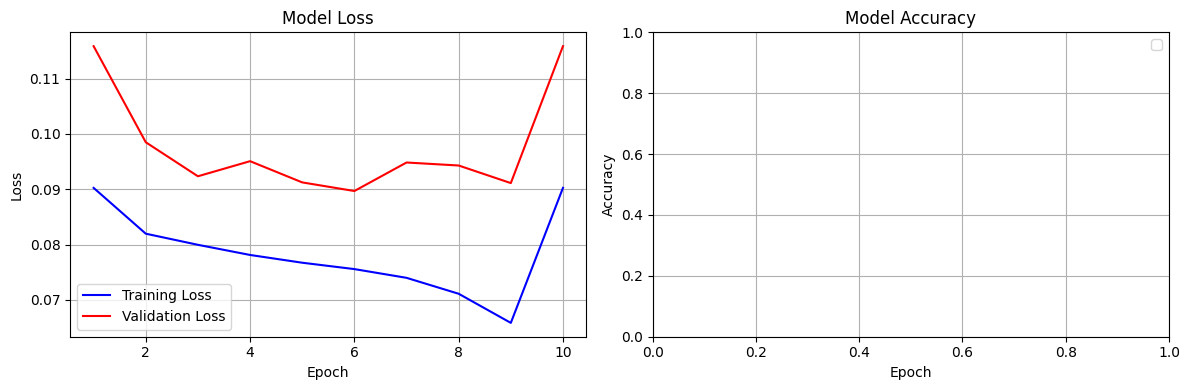

In [14]:
if True:
    for name, model in [
        ("regression_model", regression_model)
    ]:

        tags = {
            "model_type": "neural_network",
            "task": "rating_prediction",
            "dataset": "amazon_reviews",
            "variant": name
        }
 
        exp = model.log_training_history(
            run_name=f"{name}_{model.input_shape}features",
            tags=tags
        )

        print(exp)

        _ = model.plot_training_history(
            save_path=f"{METASTORE_PATH}/warehouse/gold.premodeling/training_history_{name}.png"
        )


## Cargar modelo


In [15]:
from src.utils.models import RegressionModel
regression_model = RegressionModel('regression_model', METASTORE_PATH, tracking_uri="file:///mnt/d/Maestría/Amazon Reviews Code/.mlflow")
regression_model.load_latest_model()


/mnt/d/Maestría/Amazon Reviews Code/.venv-linux/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 12 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [16]:
regression_model.list_available_models()



Available Model Versions (filtered by: regression_model)

1. Run ID: 3943f2d88b924a44aa099ceb1a3d1411
   Run Name: regression_model_1025features
   Model Name: 
   Status: FINISHED
   Start Time: 2025-10-20 02:13:33.588000+00:00
   End Time: 2025-10-20 02:13:46.420000+00:00
   Metrics: Loss: 0.0658, Val Loss: 0.0911, Accuracy: nan, Val Accuracy: nan

2. Run ID: a367c33c2d234b238b6b6133d9bd48d5
   Run Name: regression_model_1025features
   Model Name: 
   Status: FINISHED
   Start Time: 2025-10-19 18:52:24.543000+00:00
   End Time: 2025-10-19 18:52:38.216000+00:00
   Metrics: Loss: 0.0326, Val Loss: 0.0147, Accuracy: nan, Val Accuracy: nan

3. Run ID: b24560f814a349279ae85706efee135c
   Run Name: binary_model_1025features
   Model Name: 
   Status: FINISHED
   Start Time: 2025-10-19 14:17:44.462000+00:00
   End Time: 2025-10-19 14:17:56.737000+00:00
   Metrics: Loss: 0.7186, Val Loss: 0.8421, Accuracy: 0.6417, Val Accuracy: 0.5600

4. Run ID: 1c81e2c9a27545a38f0afb00612a75b9
   Run Nam

In [17]:
X_test, y_test = next(iter(regression_model.val_dataset.take(1)))


AttributeError: 'NoneType' object has no attribute 'take'

In [ ]:
X_test.shape


In [ ]:
y_pred = regression_model.predict(X_test.numpy())


In [ ]:
def predict_rating(model, features):
    if len(features.shape) == 1:
        features = features.reshape(1, -1)
    predictions = model.predict(features, verbose=0)
    return predictions

test_batch = next(iter(regression_model.val_dataset.take(1)))
X_test, y_test = test_batch
predictions = predict_rating(regression_model.model, X_test.numpy())


In [ ]:
regression_model.get_model_versions()


regression_model.get_latest_model_history()


regression_model.plot_latest_model_history()
